# FLIM Analysis of EGFP and Maroon: Isolated Protein and Transiently Expressed in U2OS

## Loading Necessary Script

In [2]:
import os
import sys
import io
import numpy as np
import scipy.optimize as optimize
import matplotlib.pyplot as plt

from matplotlib import rcParams
%config InlineBackend.figure_format='retina'
rcParams['figure.figsize'] = (16, 12)
rcParams['legend.fontsize']  = 16
rcParams['axes.labelsize'] = 16

import pq_decoding_functions as pq
import flim_fitting_functions as fit

## Fitting Simulated Data

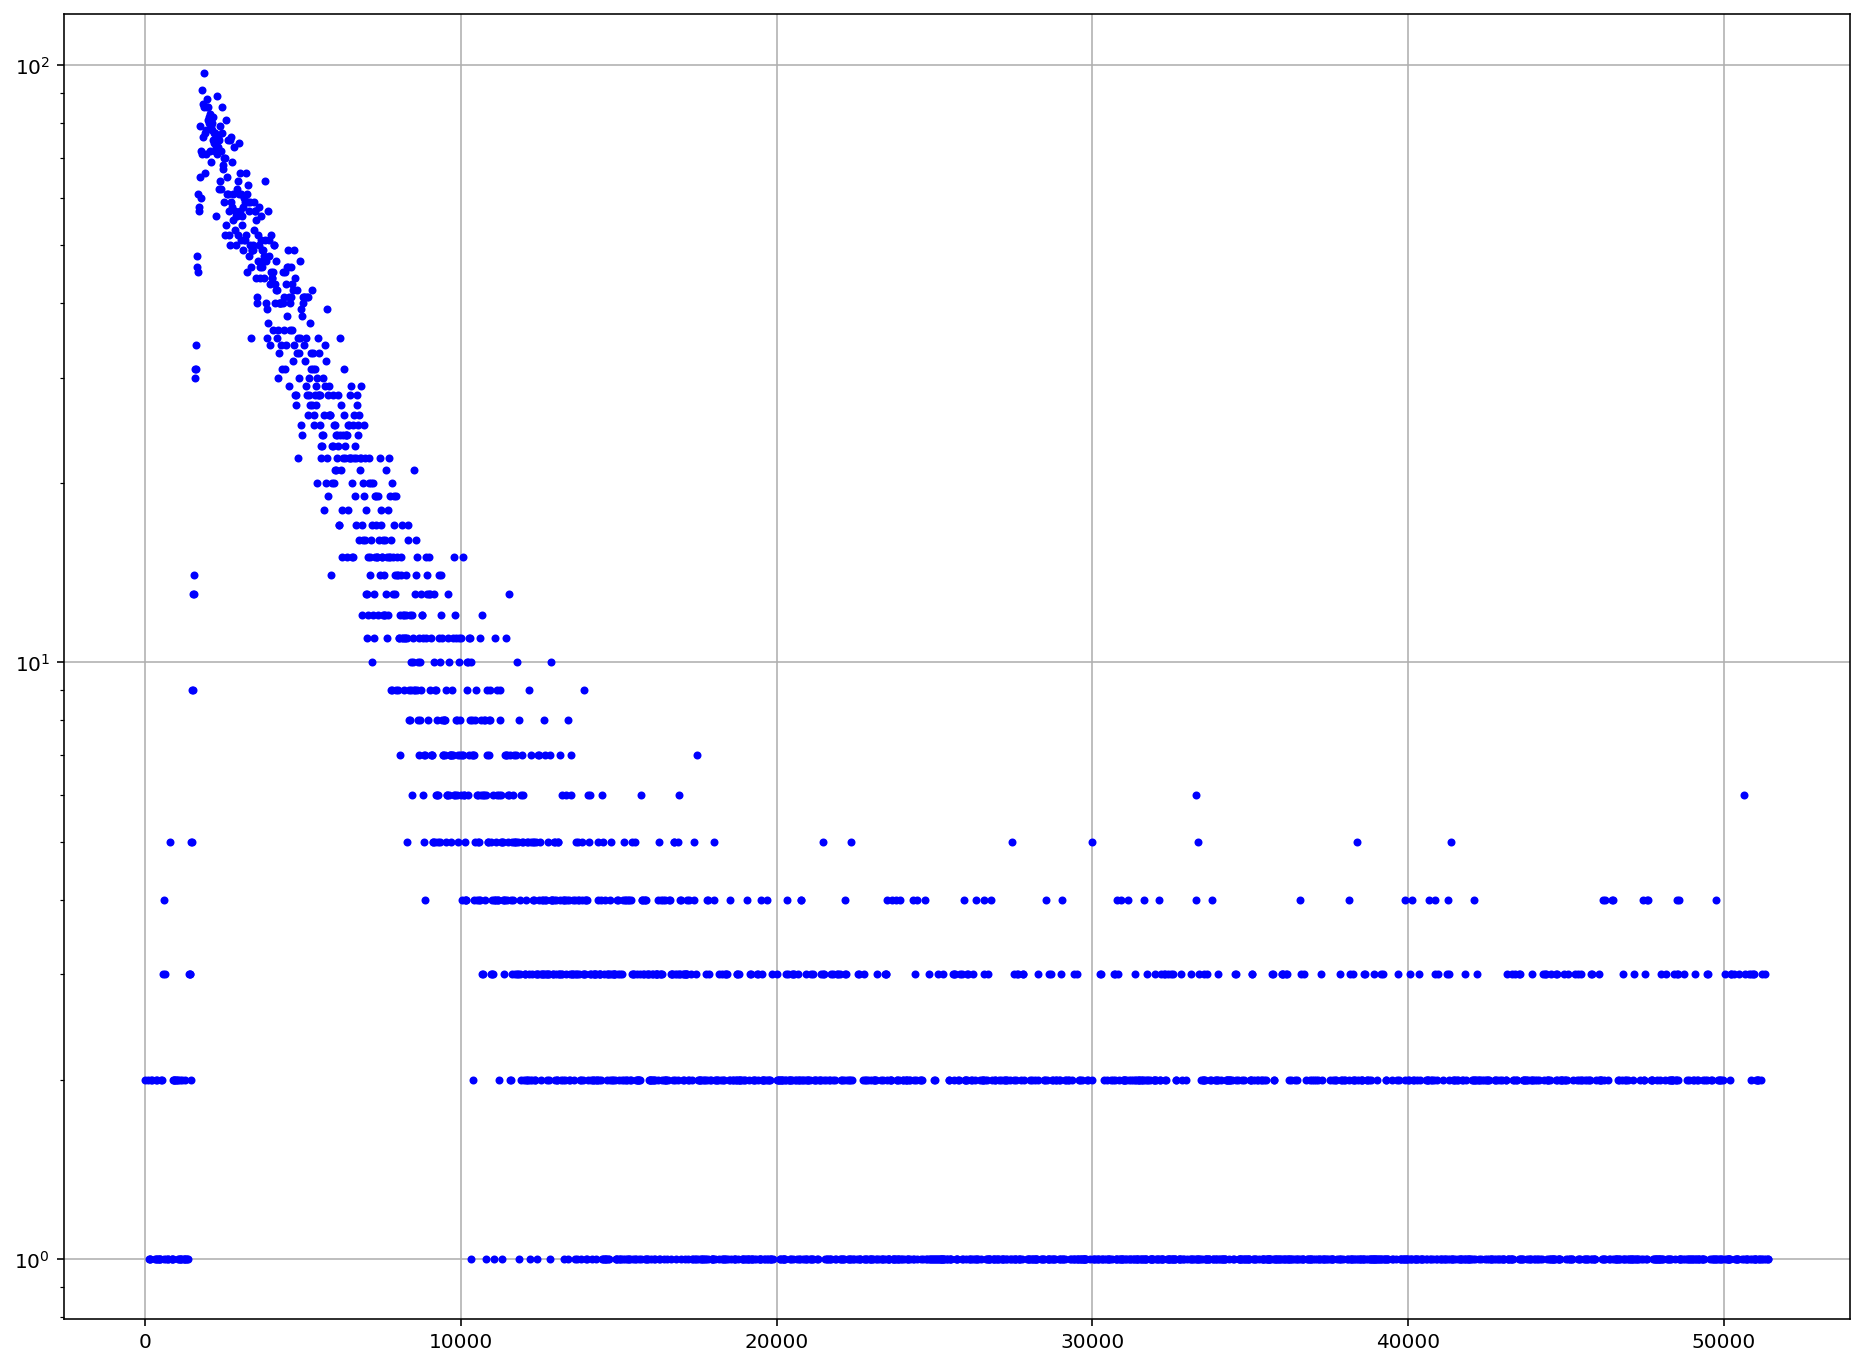

In [19]:
time_axis = pq.make_time_axis(
    global_resolution = 1/19450000,
    resolution = 1.6E-11,
)


def add_poisson_noise(data, offset):
    decay = np.random.poisson(data, len(data))
    decay += np.random.poisson(offset, len(decay))
    return(decay)

simulated = fit.convoluted_decay(
    t = time_axis,
    offset = 0,
    amp = 100,
    tau = 3210,
    IRF_mu = 1650,
    IRF_sigma = 80,
    Scatter_amplitude = 0,
    Scatter_mu = 1450
)

simulated = add_poisson_noise(simulated, offset = 1)

plt.plot(time_axis, simulated, 'b.')
plt.yscale('log')
plt.grid()
plt.show()


/home/tom/Documents/PhD/Repositories/PhasorFLIM/notebooks/flim_fitting_functions.py:142: RuntimeWarning: divide by zero encountered in log
  data * np.log(data / fitted) - (data - fitted)
/home/tom/Documents/PhD/Repositories/PhasorFLIM/notebooks/flim_fitting_functions.py:142: RuntimeWarning: invalid value encountered in multiply
  data * np.log(data / fitted) - (data - fitted)
/home/tom/Documents/PhD/Repositories/PhasorFLIM/notebooks/flim_fitting_functions.py:104: RuntimeWarning: overflow encountered in true_divide
  weights = 1.0 / np.sqrt(data, where = (data != 0))


Reduced Chi-Squared: 0.900309371435413


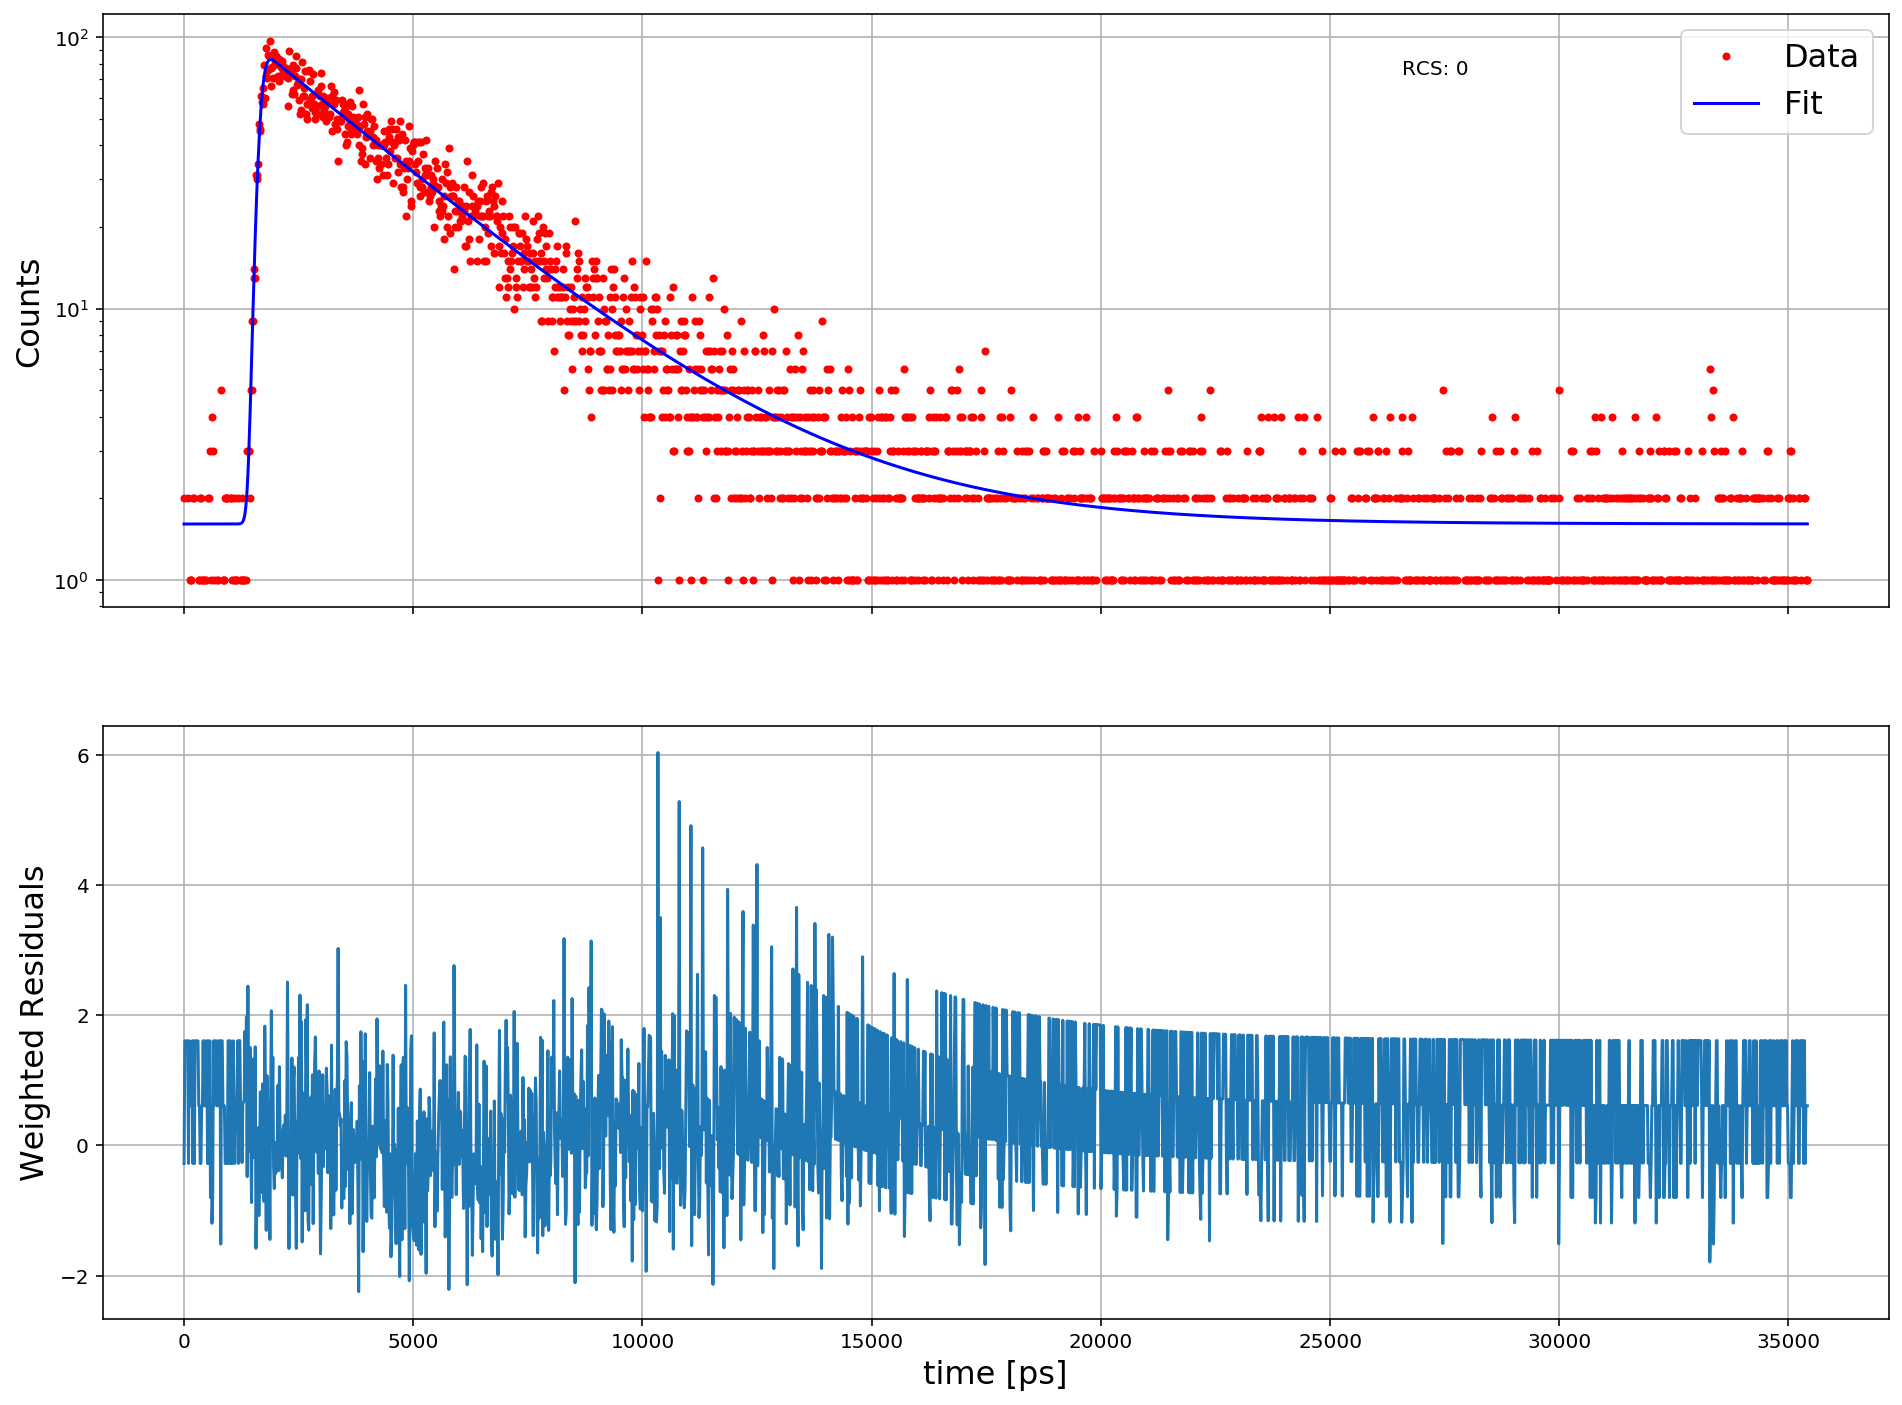

offset 		 1.608671713855084
amplitude 		 100.47436835360402
tau 		 3106.9460403697867
IRF_mu 		 1654.1330371429099
IRF_sigma 		 76.71759126741084
Scatter_amp 		 0.0
Scatter_mu 		 1509.0183969373643


In [20]:
# Fitting simulated data
parameter_names, estimated_parameters, parameter_bounds = fit.make_start_parameters(
    offset = 2,
    amplitude = max(simulated),
    Scatter_amplitude = 100,
    tau = 2000,
    #IRF_sigma = 25
)

simulated_fit = fit.fit_decay(
    simulated,
    time_axis,
    estimated_parameters,
    parameter_bounds,
    cutoff = 1000,
    minimization_method = 'SLSQP'
)

fit.plot_fit(simulated, time_axis, simulated_fit, cutoff = 1000, scale = 'log')

for i in range(0, len(parameter_names)):
    print(parameter_names[i], '\t\t', simulated_fit['x'][i])


## EGFP
### Transient Expression

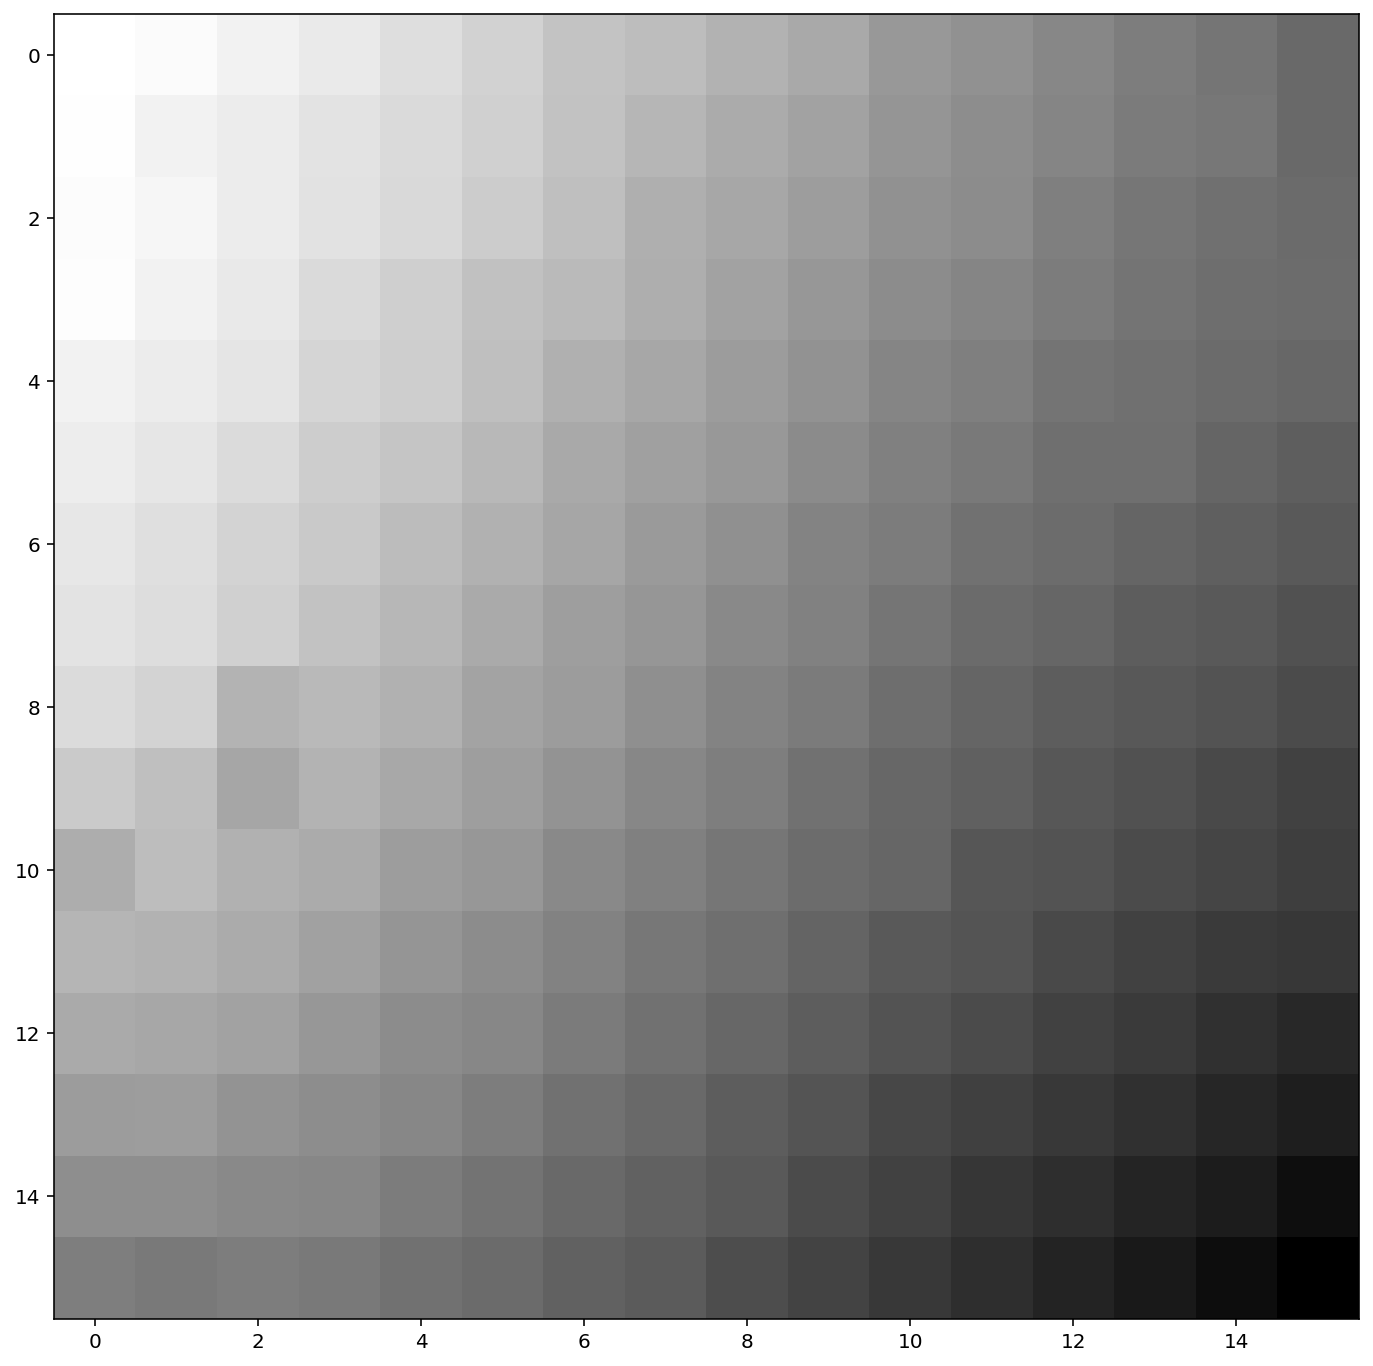

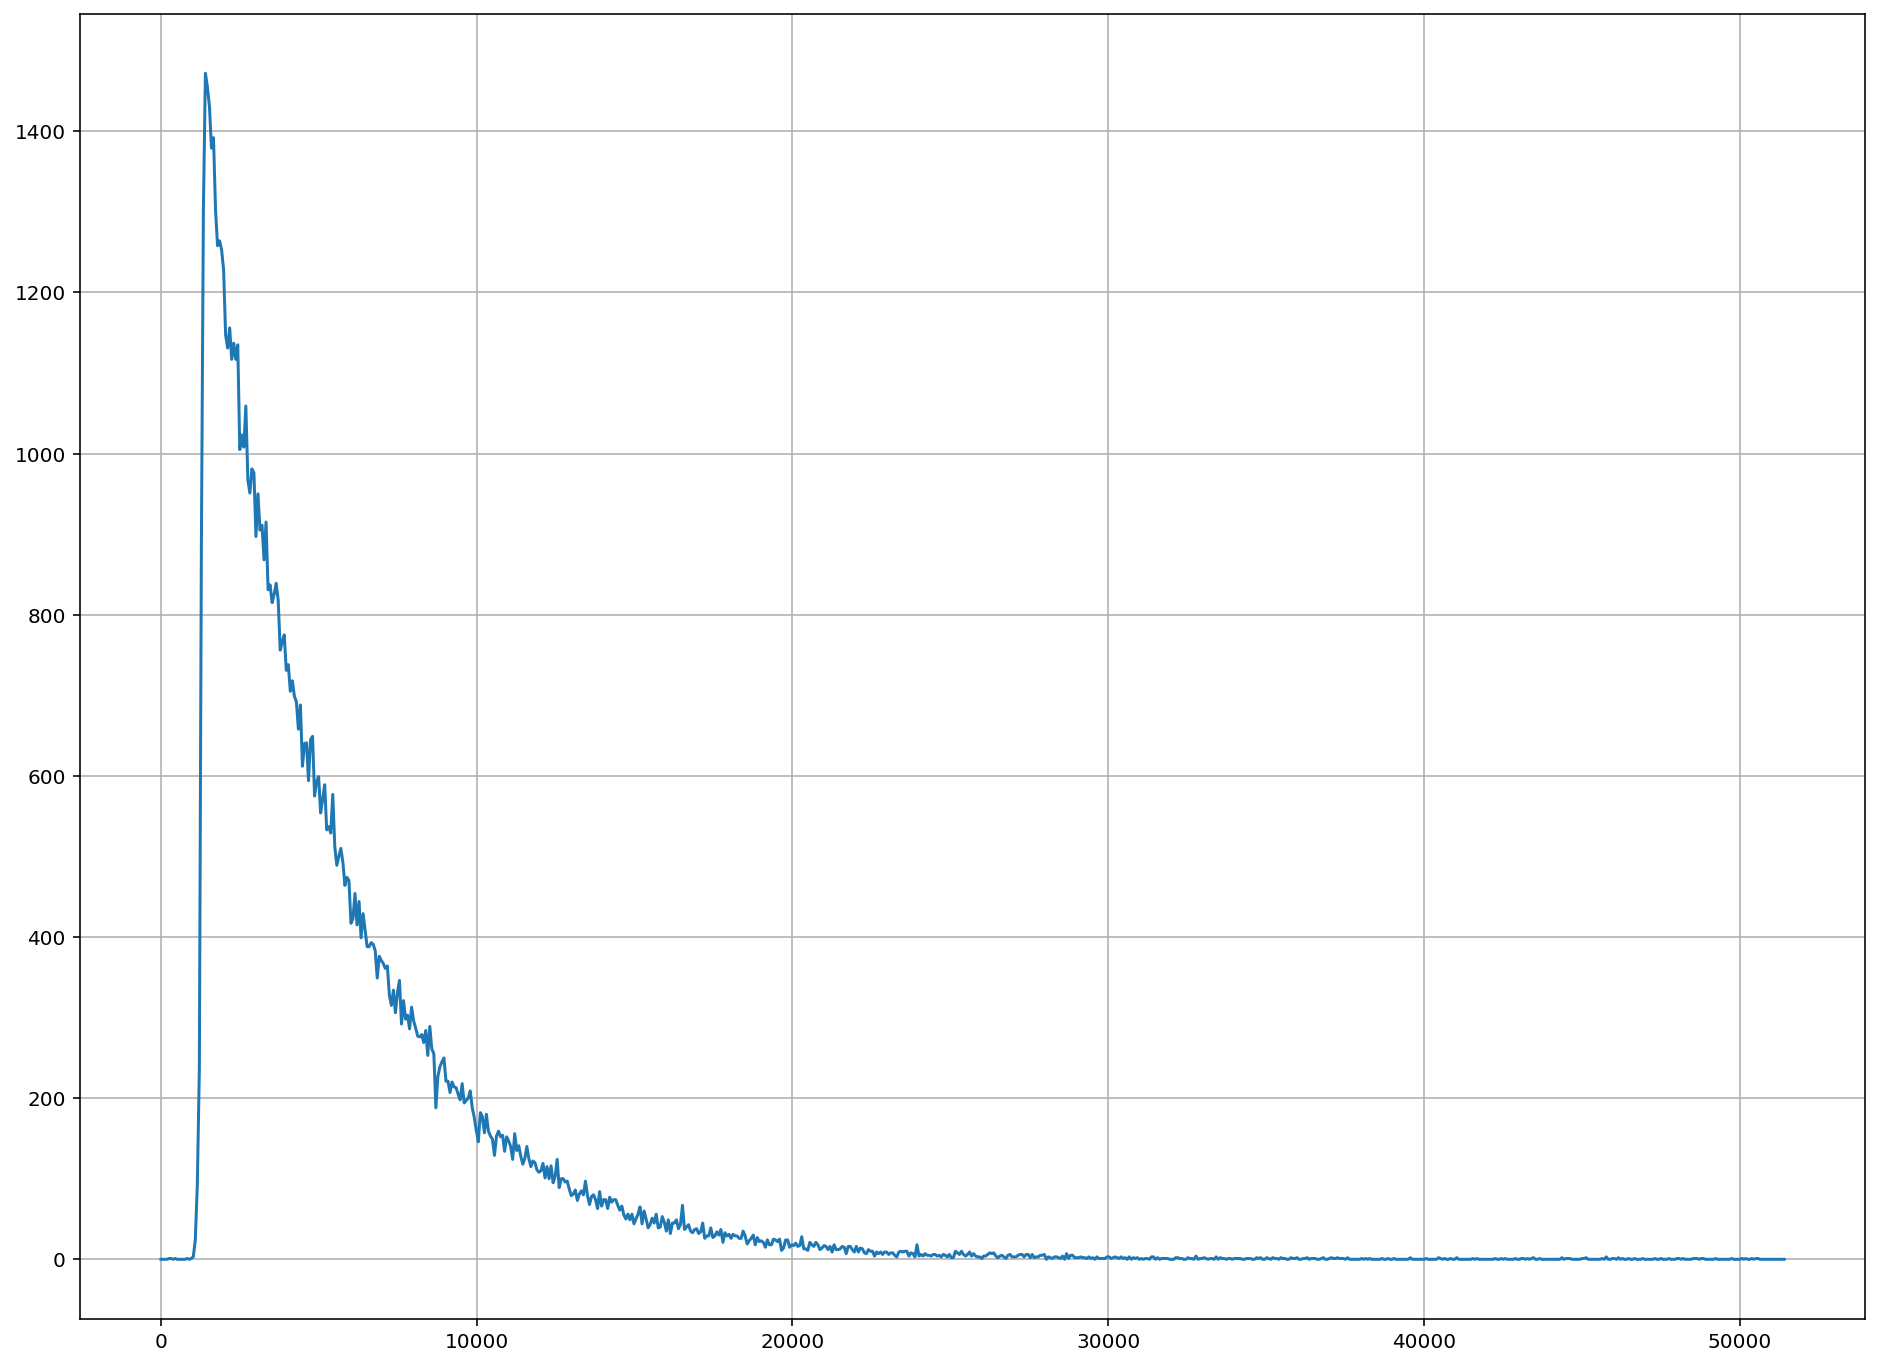

In [86]:
ptu_path = '../../../FLIM Data/Praktikum_Biochemie/raw_data/FP_EGFP_Maroon_200312.sptw/Kontrolle_Sulforhodamine101_10µM_1_1_1.ptu'
EGFP_cell_fa, EGFP_cell_ii, time_axis= pq.load_flim_data(
    path = ptu_path,
    channel = 1,
    spatialBinning = 5,
    temporalBinning = 2
)

plt.imshow(EGFP_cell_ii, cmap = 'gray')
plt.show()

EGFP_decay = fit.sum_up_decay(EGFP_cell_fa)
EGFP_decay = fit.sum_up_decay(EGFP_cell_fa[12:13, 4:5, :])

plt.plot(time_axis, EGFP_decay)
plt.grid()
plt.show()

In [98]:
parameter_names, estimated_parameters, parameter_bounds = fit.make_start_parameters(
    offset = 2,
    amplitude = max(EGFP_decay),
    Scatter_amplitude = 0,
    tau = 3000
    #IRF_sigma = 25
)

EGFP_fit = fit.fit_decay(
    EGFP_decay,
    time_axis,
    estimated_parameters,
    parameter_bounds,
    cutoff = 100,
    minimization_method = 'SLSQP'
)


Reduced Chi-Squared: 0.9244022035238935


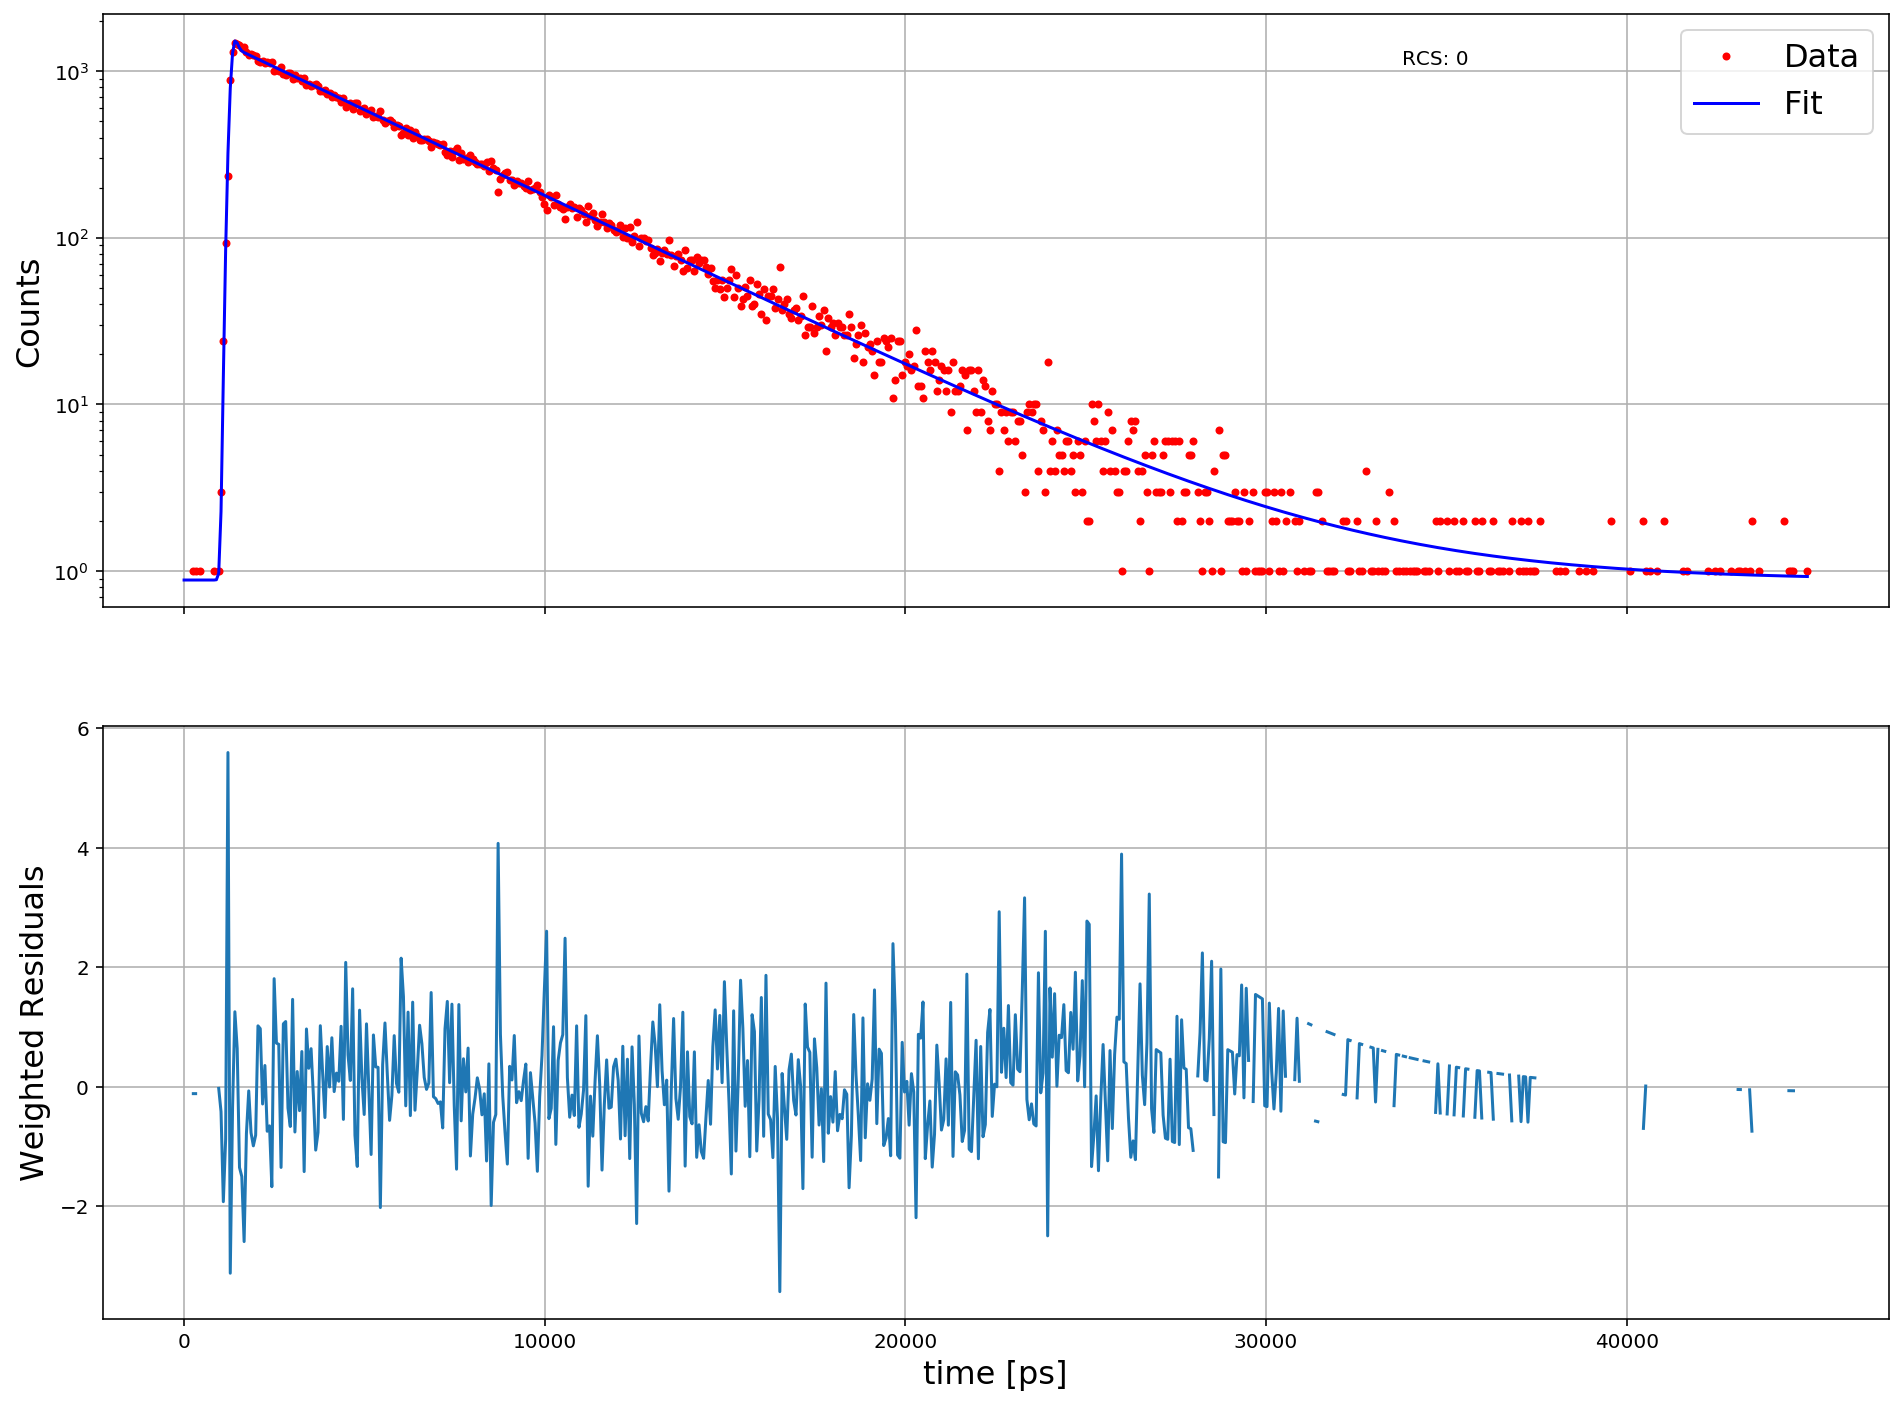

offset 		 0.8842480392643082
amplitude 		 6184.803087700447
tau 		 4212.125887384608
IRF_mu 		 1433.2332087059601
IRF_sigma 		 65.01983496957145
Scatter_amp 		 2.471179835477255
Scatter_mu 		 1356.6369936368108


In [99]:
fit.plot_fit(EGFP_decay, time_axis, EGFP_fit, cutoff = 100, scale = 'log')

for i in range(0, len(parameter_names)):
    print(parameter_names[i], '\t\t', EGFP_fit['x'][i])

In [100]:
# Pixel-wise fitting

flim_image = np.zeros((EGFP_cell_fa.shape[0], EGFP_cell_fa.shape[1], EGFP_fit['x'].shape[0]))

for x in range(EGFP_cell_fa.shape[0]):
    for y in range(EGFP_cell_fa.shape[1]):
        #estimated_parameters = EGFP_fit['x']
        if(np.sum(EGFP_cell_fa[x, y, :]) > 300):
            EGFP_fit = fit.fit_decay(
                EGFP_cell_fa[x, y, :],
                time_axis,
                estimated_parameters,
                parameter_bounds,
                cutoff = 750,
                minimization_method = 'SLSQP'
            )
            flim_image[x, y, :] = EGFP_fit['x']
    print('Proceeding to line', x)

Proceeding to line 0
Proceeding to line 1
Proceeding to line 2
Proceeding to line 3
Proceeding to line 4
Proceeding to line 5
Proceeding to line 6
Proceeding to line 7
Proceeding to line 8
Proceeding to line 9
Proceeding to line 10
Proceeding to line 11
Proceeding to line 12
Proceeding to line 13
Proceeding to line 14
Proceeding to line 15


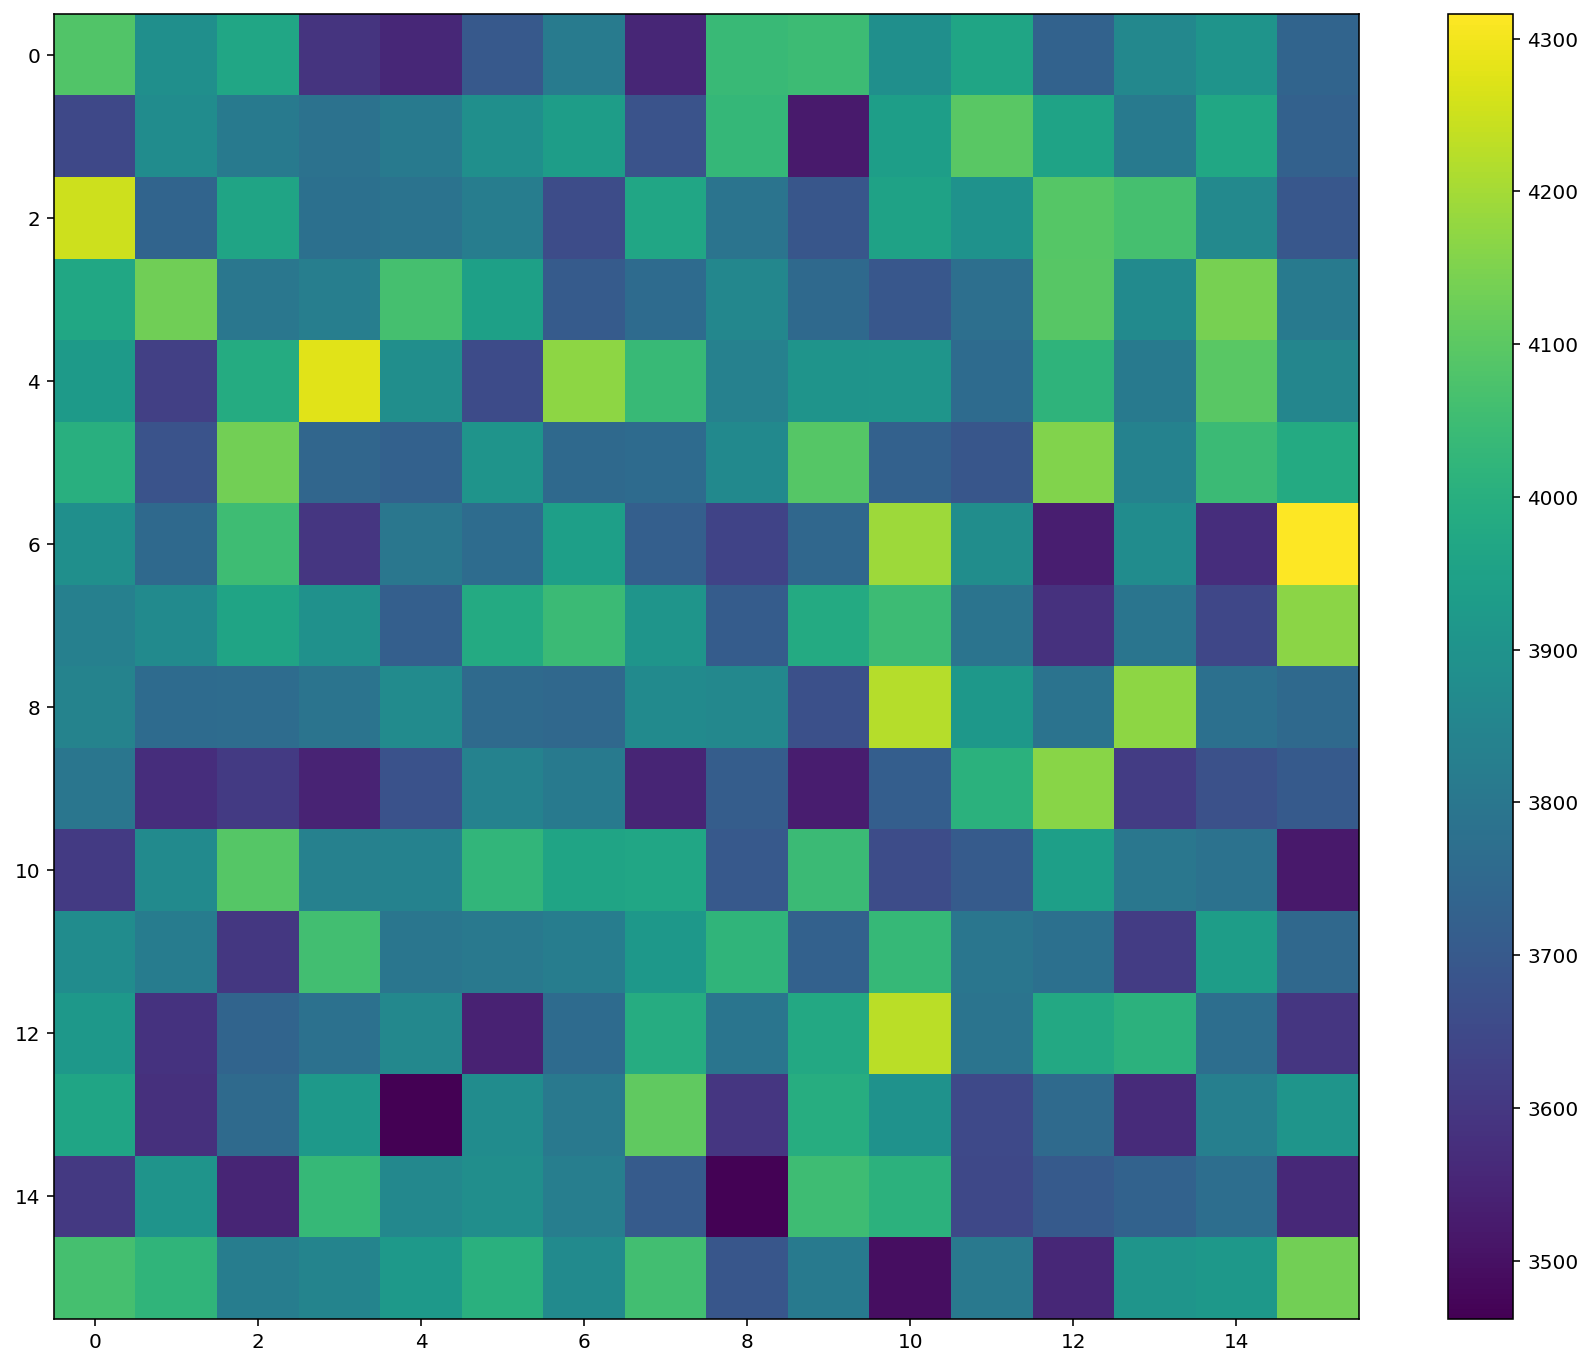

In [110]:
plt.imshow(flim_image[:, :, 2])
plt.colorbar()
plt.show()

In [17]:
EGFP_fit['x'][1]

908.3338932910884